In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
or_img = cv2.imread('../dataset/shadow/_MG_6147.jpg')

In [3]:
y_cb_cr_img = cv2.cvtColor(or_img, cv2.COLOR_BGR2YCrCb)
#cv2.imshow("ycrcb",y_cb_cr_img)
# copy the image to create a binary mask later
binary_mask = np.copy(y_cb_cr_img)

# get mean value of the pixels in Y plane
y_mean = np.mean(cv2.split(y_cb_cr_img)[0])

# get standard deviation of channel in Y plane
y_std = np.std(cv2.split(y_cb_cr_img)[0])

# classify pixels as shadow and non-shadow pixels
for i in range(y_cb_cr_img.shape[0]):
    for j in range(y_cb_cr_img.shape[1]):

        if y_cb_cr_img[i, j, 0] < y_mean - (y_std / 3):
            # paint it white (shadow)
            binary_mask[i, j] = [255, 255, 255]
        else:
            # paint it black (non-shadow)
            binary_mask[i, j] = [0, 0, 0]

#cv2.imshow("binary",binary_mask)

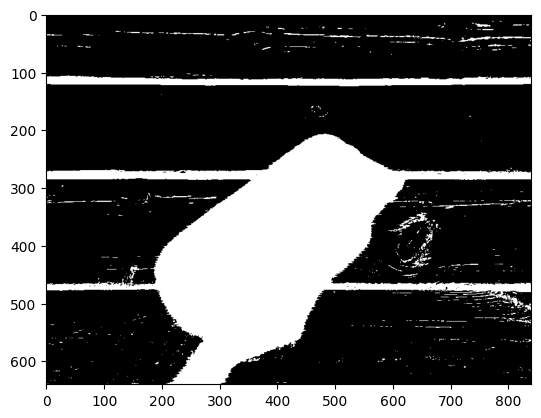

In [15]:
plt.imshow(binary_mask[:,:,0],cmap='gray')

In [19]:
dft = cv2.dft(np.float32(binary_mask[:,:,0]),flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
print(dft_shift.shape)
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))
rows, cols = dft_shift.shape[0],dft_shift.shape[1]
crow, ccol = rows//2, cols//2

(640, 840, 2)


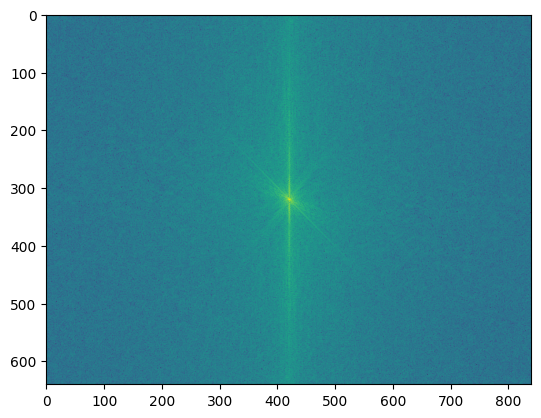

In [22]:
plt.imshow(magnitude_spectrum)

In [25]:
mask = np.ones((rows, cols, 2), np.uint8)
filter_size = 10
mask[crow-filter_size:crow+filter_size, ccol-filter_size:ccol+filter_size] = 0

# 应用滤波器
fshift = dft_shift * mask

# 把频域图像转换回空间域
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

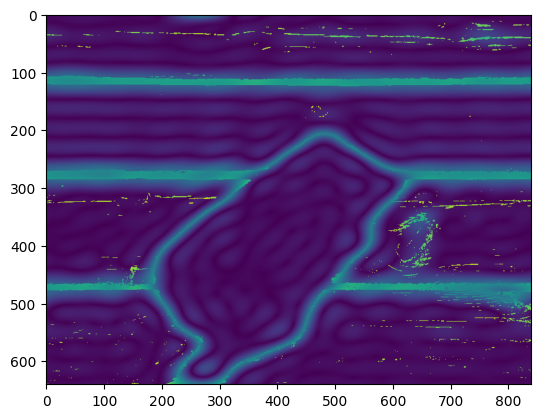

In [26]:
plt.imshow(img_back)

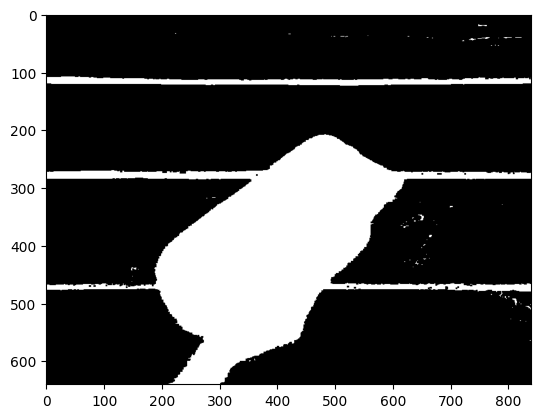

In [8]:
# Using morphological operation
# The misclassified pixels are removed using dilation followed by erosion.
kernel = np.ones((3, 3), np.uint8)
erosion = cv2.erode(binary_mask, kernel, iterations=1)
plt.imshow(erosion)